In [37]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace
from IPython.display import clear_output
import pandas as pd

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import (run_extract, run_stack, read_galaxy_fits, measure, plotting, analysis, multicat,
core, PipelineConfig, stack, selection)
from utils_lya_halo.io import read_galaxy_fits, apply_finite_cut
from utils_lya_halo.measure import measure_all_bins, integrated_line_flux
from utils_lya_halo.stack import build_stacks

%matplotlib inline

LYA_REST = PipelineConfig.LYA_REST

import warnings
from astropy.utils.exceptions import AstropyUserWarning

warnings.filterwarnings(
    "ignore",
    message="Input data contains invalid values.*",
    category=AstropyUserWarning,
)

# Reading in output and stacking

In [9]:
# ---------------------------------------------------------------- INPUTS
random_seed     = 10
bin_mode        = 'kpc'
bins            = [0, 10, 20, 30, 50, 80, 140, 300, 600, 1000, 2000]
field           = 'BOTH'

half_width      = 3.0            # +/- Angstrom around LYA_REST used as the "line" (Stage 3)
vr_approx       = 80             # rough |v| scale (km/s) -- not consumed in this cell;
                                # handy later e.g. plot_centroid_profile(..., ylims=(-3*vr_approx, 3*vr_approx))
stack_method    = 'biweight'
mask_method     = "segmap"

id_col          = "ID"

bg_inner_arcsec = 80
bg_outer_arcsec = 90

rest_wave_min   = 1100
rest_wave_max   = 1700
spexlim         = (rest_wave_min, rest_wave_max)

n_bootstrap     = 5000
np.random.seed(random_seed)    # reproducibility for anything you resample by hand below

# ---------------------------------------------------------------- CONFIG (drives everything below)
cfg2 = replace(cfg,
    field=field,
    bin_mode=bin_mode,
    bins=bins,
    mask_method=mask_method,
    bg_inner_arcsec=bg_inner_arcsec,
    bg_outer_arcsec=bg_outer_arcsec,
    rest_wave_min=rest_wave_min,
    rest_wave_max=rest_wave_max,
    n_bootstrap=n_bootstrap,
    #flux_unit='flux_arcsec2',
    #rest_density=False,
    line_window=[LYA_REST - half_width, LYA_REST + half_width])

# ---------------------------------------------------------------- FILE PATHS
# one dict keyed by bin_mode -- add a new bin_mode by adding a key, no new elif
PRODUCT_PATHS = {
    'virial': {
        'AEGIS':  './outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits',
        'COSMOS': './outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits',
    },
    'kpc': {
        'AEGIS':  './outputs/galaxy_cat65a007_b10_ec8c16_AEGIS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
        'COSMOS': './outputs/galaxy_cat65a007_b10_ec8c16_COSMOS_MOSDEF_kpc_biweight_segmap_bg80-90.fits',
    },
}
try:
    paths = PRODUCT_PATHS[bin_mode.lower()]
except KeyError:
    raise ValueError(f"No file paths registered for bin_mode={bin_mode!r} "
                     f"(have: {list(PRODUCT_PATHS)}); add it to PRODUCT_PATHS.")

# ---------------------------------------------------------------- LOAD + CUT (per field)
products = {
    label: apply_finite_cut(read_galaxy_fits(path),
                            cfg2.cut_radial_bin, cfg2.min_good_wave)
    for label, path in paths.items()
}
product1, product2 = products['AEGIS'], products['COSMOS']   # kept for compatibility with older cells

# ---------------------------------------------------------------- (BOTH) COMBINE + STACK
prod_combined = multicat.combine_products(products, label_col="SUBSET")

print(f"AEGIS: {np.round(np.median(product1.nfib, axis=0), 3).astype(int)}")
print(f"COSMOS: {np.round(np.median(product2.nfib, axis=0), 3).astype(int)}")
print(f"COMBINED: {np.round(np.median(prod_combined.nfib, axis=0), 3).astype(int)}")

# ---------------------------------------------------------------- (SINGLE) COMBINE + STACK
stacks_by_field = multicat.stack_each(cfg2, products, keep_cube=True)   # {'AEGIS':stacks,'COSMOS':stacks}
stacks_all = stack.build_stacks(cfg2, prod_combined, keep_cube=True)

print(f"BOTH:   {prod_combined.ngal} galaxies")
print(f"AEGIS:  {products['AEGIS'].ngal} galaxies")
print(f"COSMOS: {products['COSMOS'].ngal} galaxies")

# ---------------------------------------------------------------- SEPARATE AGN
sel_agn = prod_combined.catalog["CLEAN"]

groups = selection.split_by_mask(prod_combined, sel_agn, labels=["AGN", "GAL"], verbose=False)
prod_galaxy = groups['GAL']
prod_agn = groups['AGN']

stacks = build_stacks(cfg2, prod_galaxy, keep_cube=True)
stacks_agn = build_stacks(cfg2, prod_agn, keep_cube=True)

print(f"GAL: {prod_galaxy.ngal} sources")
print(f"AGN: {prod_agn.ngal} sources")

Finite-spectrum cut (bin 9, > 100 px): kept 233 / 244 galaxies
Finite-spectrum cut (bin 9, > 100 px): kept 277 / 278 galaxies
combined 2 products -> 510 galaxies (origin in column 'SUBSET')
AEGIS: [    24     70    115    373    911   3128  16911  62091 126573 586721]
COSMOS: [    15     43     70    220    536   1809   9820  37073  87936 402380]
COMBINED: [    17     51     81    258    615   2038  10906  41317  97244 448919]
BOTH:   510 galaxies
AEGIS:  233 galaxies
COSMOS: 277 galaxies
GAL: 443 sources
AGN: 67 sources


# Measuring

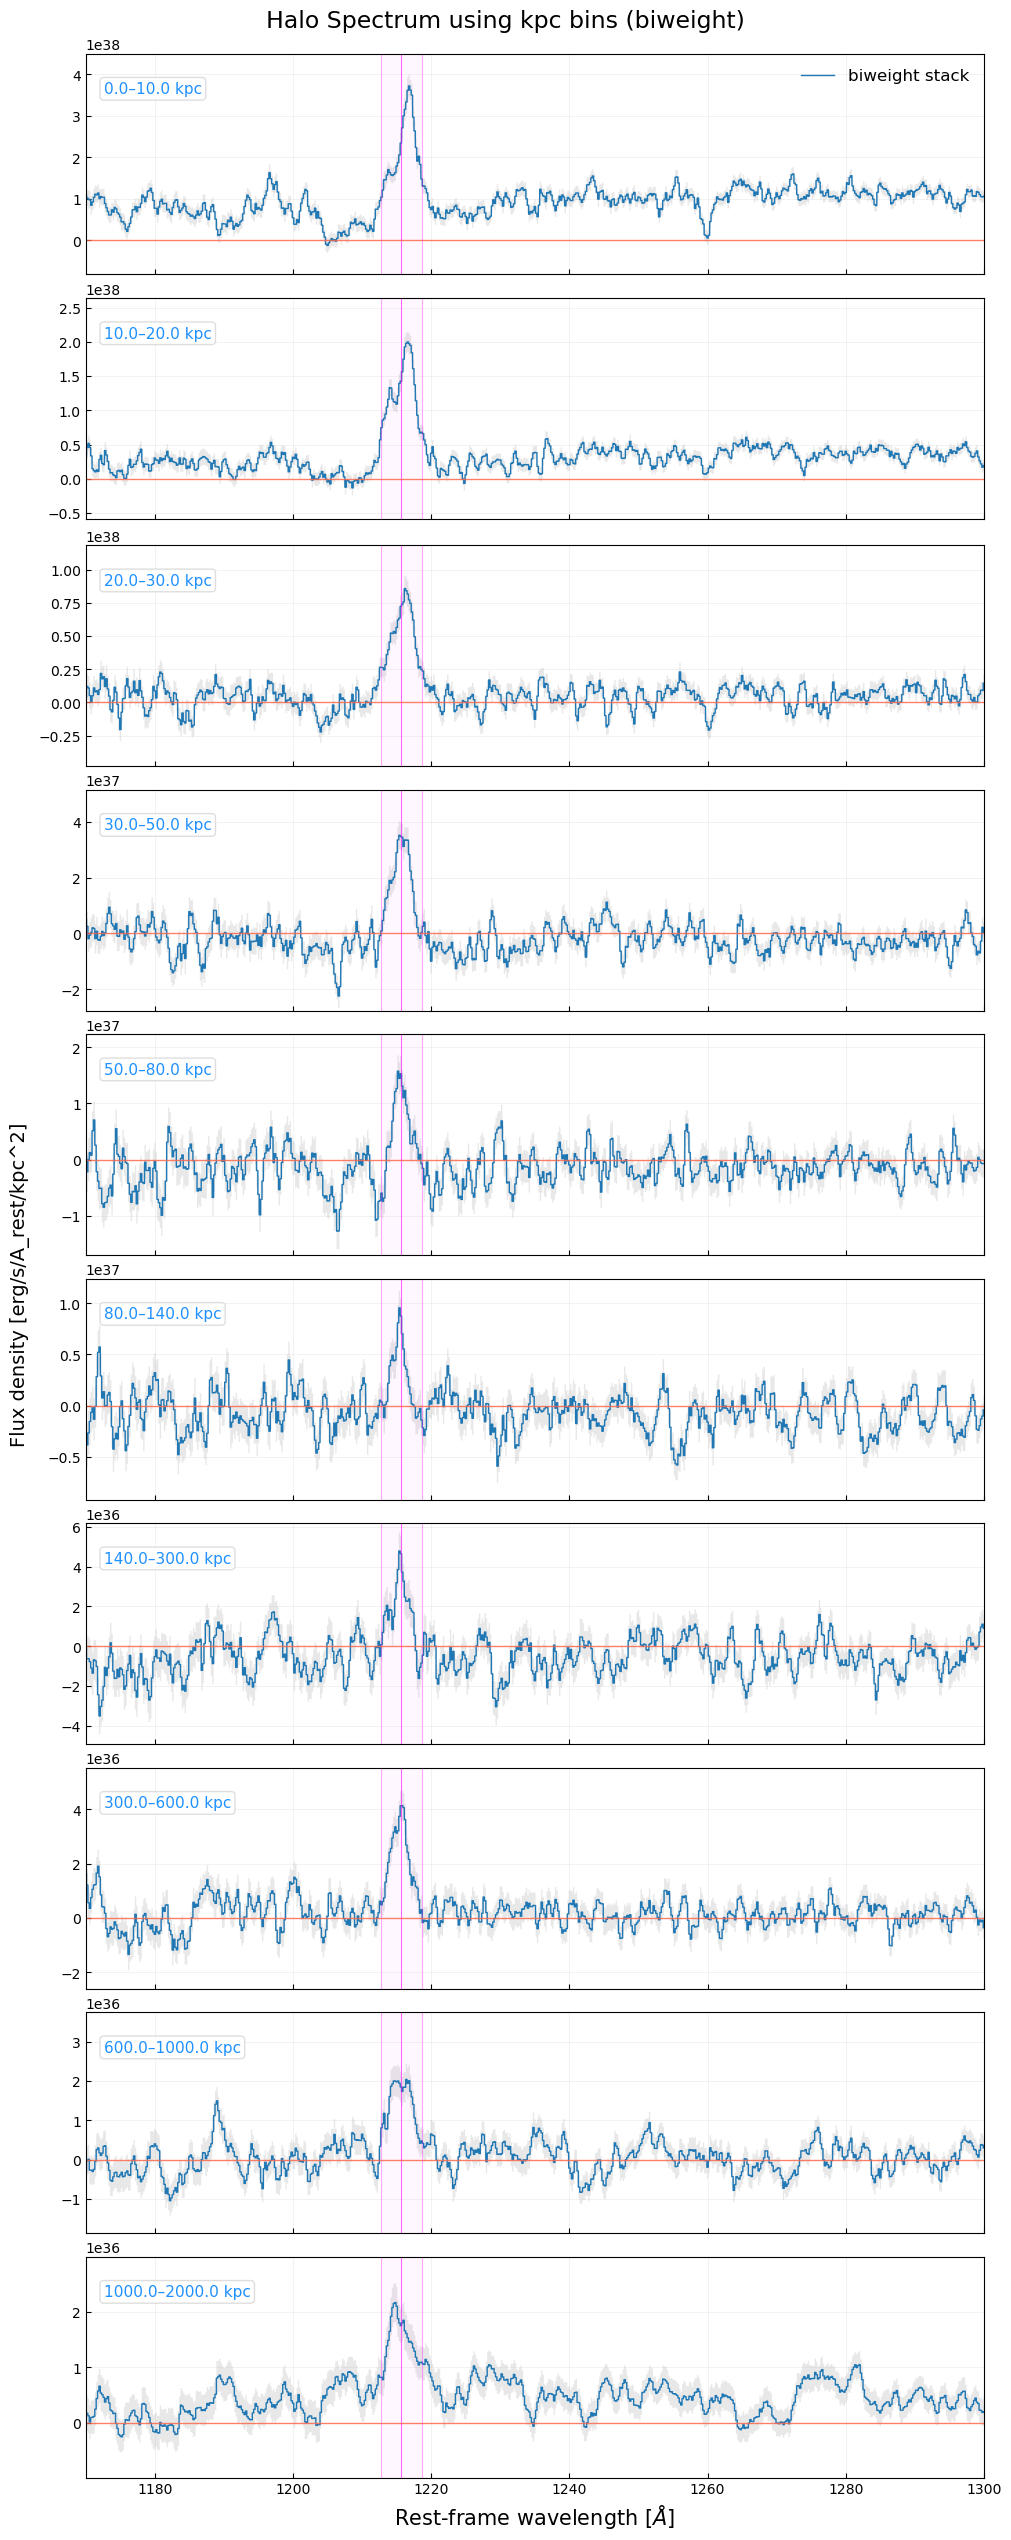

(<Figure size 1000x2500 with 10 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Rest-frame wavelength [$\\AA$]'>], dtype=object))

In [3]:
plotting.plot_stack_panels(stacks,
    method="biweight",
    distance_type=bin_mode,
    title=None,
    xlim=(1170, 1300),
    lya_window=half_width,
    figsize_width=10,
    panel_height=2.5,
    show_err=True,
    smooth=None,
    savepath=None,
    dpi=300)

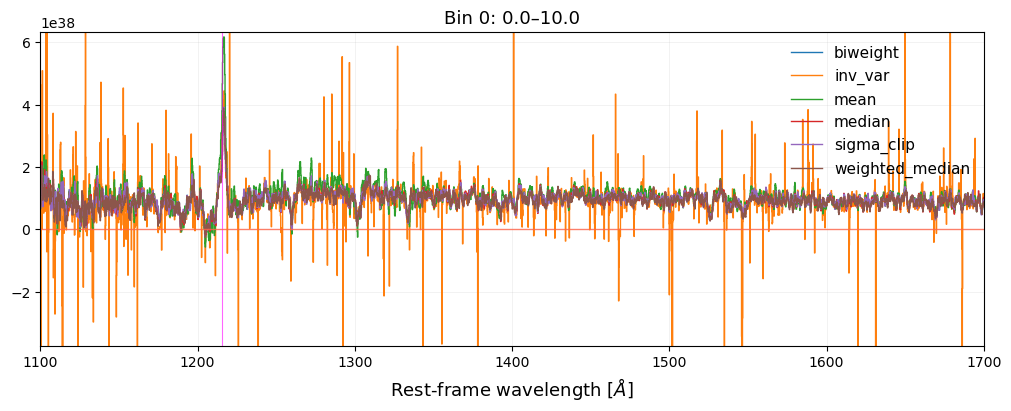

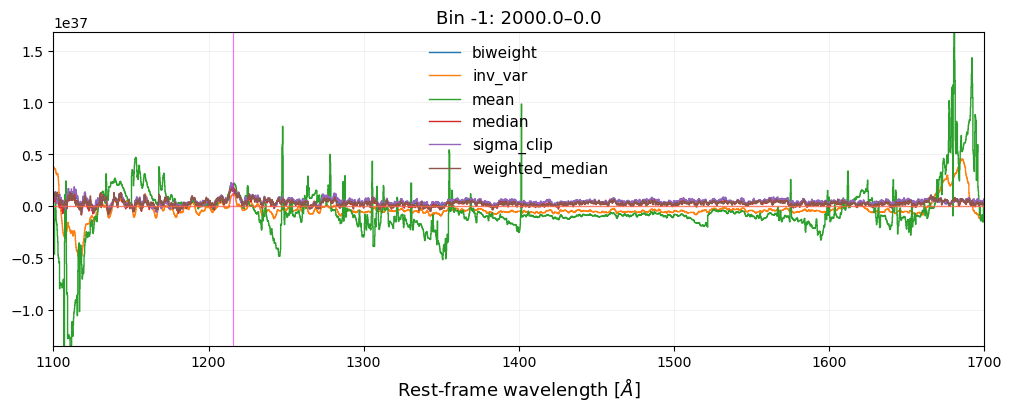

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Bin -1: 2000.0–0.0'}, xlabel='Rest-frame wavelength [$\\AA$]'>)

In [8]:
plotting.plot_methods_overlay(stacks,
    methods=None,
    radial_index=0,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

plotting.plot_methods_overlay(stacks,
    methods=None,
    radial_index=-1,
    xlim=spexlim,
    smooth=None,
    title=None,
    set_ylim=True,
    ylim_pad=0.25,
    ylim_percentiles=(1, 99),
    include_zero=False)

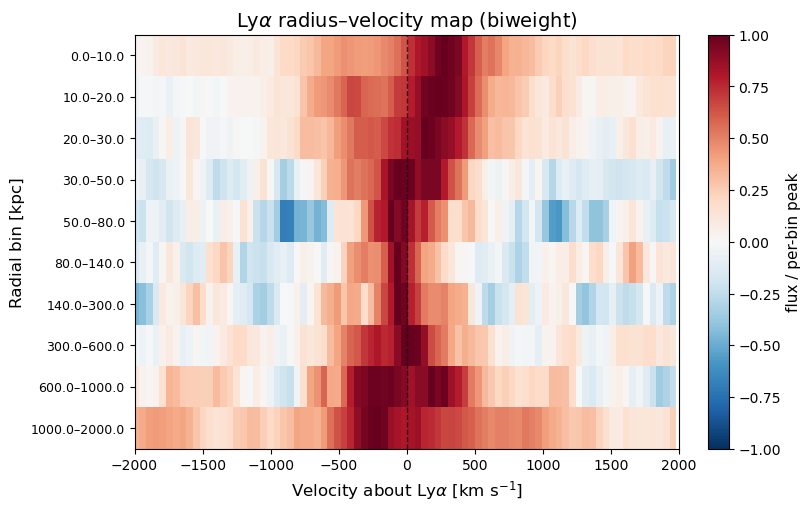

(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'Ly$\\alpha$ radius–velocity map (biweight)'}, xlabel='Velocity about Ly$\\alpha$ [km s$^{-1}$]', ylabel='Radial bin [kpc]'>)

In [9]:
plotting.plot_radius_velocity_map(stacks,
    method="biweight",
    distance_type=bin_mode,
    vlim=(-2000, 2000),
    normalize="peak",
    cmap="RdBu_r",
    smooth=None,
    show_window=None,
    title=None,
    figsize=(8, 5),
    savepath=None,
    dpi=300)

# Bootstrap Pipeline

In [10]:
boot_b = measure.measure_all_bins(cfg2, stacks,
    seed=random_seed,
    verbose=True)

# flux_rf = stacks['cube_flux']
# err_rf  = stacks['cube_err']
# wave    = stacks['rest_wave']

# boot_m = measure.bootstrap_all(flux_rf, err_rf, wave,
#     nboot=cfg2.n_bootstrap,
#     bounds=cfg2.line_window,
#     stack_method="mean",
#     compute_side_ratio=True,
#     compute_stack_error=True,
#     robust_stack_error=True,
#     seed=random_seed, verbose=True,
#     weights=None,
#     sigma_clip_sigma=3.0, sigma_clip_maxiters=5,
# )

# boot_s = measure.bootstrap_all(flux_rf, err_rf, wave,
#     nboot=cfg2.n_bootstrap,
#     bounds=cfg2.line_window,
#     stack_method="sigma_clip",
#     compute_side_ratio=True,
#     compute_stack_error=True,
#     robust_stack_error=True,
#     seed=random_seed, verbose=True,
#     weights=None,
#     sigma_clip_sigma=3.0, sigma_clip_maxiters=5,
# )

▶ bootstrap [median50]  |  nboot=5000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=11


bootstrap [median50]:   0%|          | 0/5000 [00:00<?, ?it/s]

In [11]:
boot = boot_b

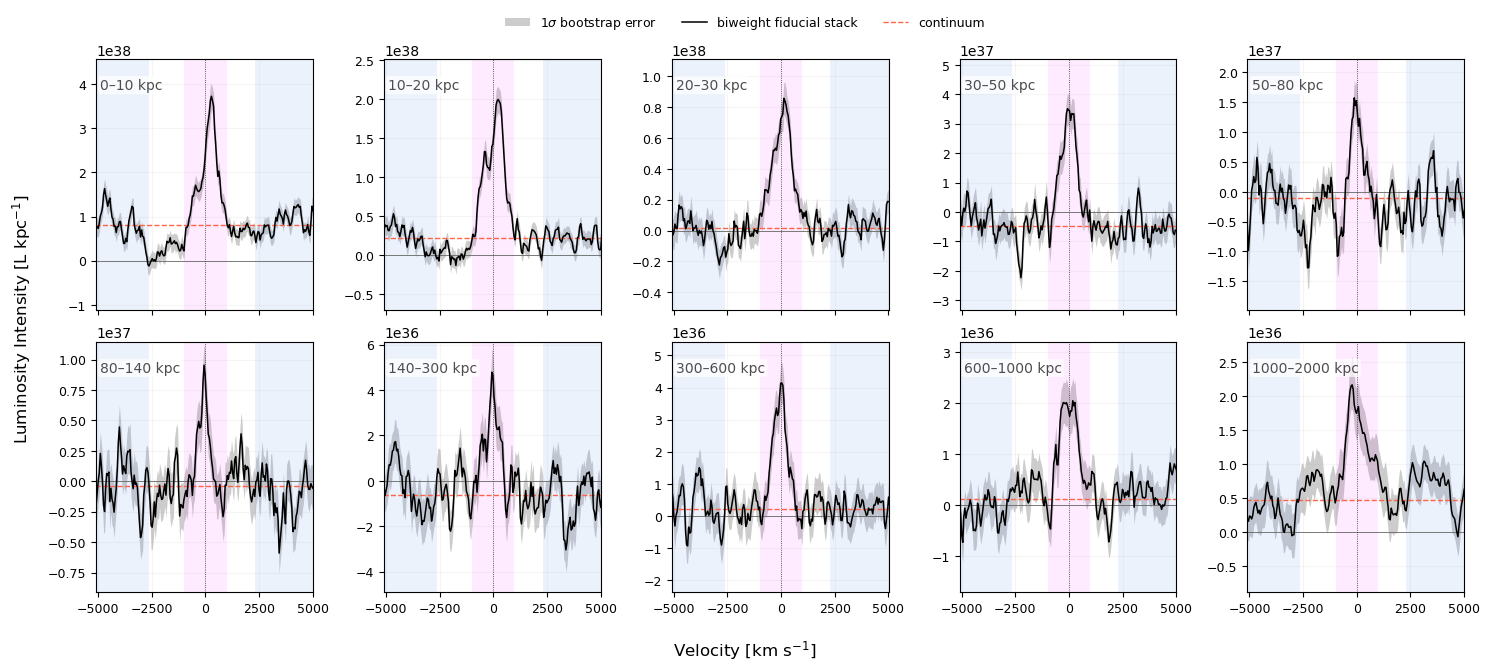

Figure 1: Spectra Panels


In [42]:
analysis.plot_line_panels(
    stacks, boot_b,
    stack_method="biweight",
    bounds=None,
    cont_bounds=cfg2.cont_bounds,
    cont_method="median",
    cont_order=1,
    lya_center=1215.67,
    xlim=(1195, 1236),
    xunit="velocity",        # "wavelength" (Å) or "velocity" (km/s, v=0 at lya_center)
    panel_height=3.5,
    figwidth=15,
    ncols=5,
    fill_order="row",          # "row" = left-to-right then wrap; "col" = top-to-bottom then next column
    show_cont=True,
    show_window=True,
    show_sidebands=True,
    show_centroid=False,       # save this for the centroid-vs-radius plot
    stack_color="k",
    band_color="0.80",
    band_alpha=1.0,
    cont_color="tomato",
    window_color="magenta",
    window_alpha=0.08,
    sideband_color="cornflowerblue",
    sideband_alpha=0.12,
    centroid_color="magenta",
    lya_line_color="0.2",
    zero_color="0.4",
    label_fontsize=10,        # per-panel "0-10 kpc" corner text
    legend_fontsize=9,
    tick_fontsize=9,
    xlabel_fontsize=12,
    ylabel_fontsize=12,
    title_fontsize=16,
    xlabel_text=None,
    ylabel_text=r"Luminosity Intensity [L kpc$^{-1}$]",
    title_text="",           # None -> auto "Lyα line panels — {method} stack"
    xlabel_y=0.01,             # vertical position of the shared x-axis label
    ylabel_x=0.01,             # horizontal position of the shared y-axis label
    title_y=None,              # None -> auto (above the legend strip in grid mode)
    legend_y=0.95,             # legend position when ncols>1
    top_margin=0.87,           # fraction of figure height given to the grid; lower = more room above for legend/title
    band_label=r"1$\sigma$ bootstrap error",
    stack_label=r"biweight fiducial stack",          # None -> f"{stack_method} stack"
    cont_label="continuum",
    save_fig=False,
    savename="Spectra_Panels.png",
)

print('Figure 1: Spectra Panels')

In [12]:
cog = measure.flux_curve_of_growth(boot, stacks, 
    r_max_kpc=None,
    drop_last_bin=False,
    area_combine="biweight")

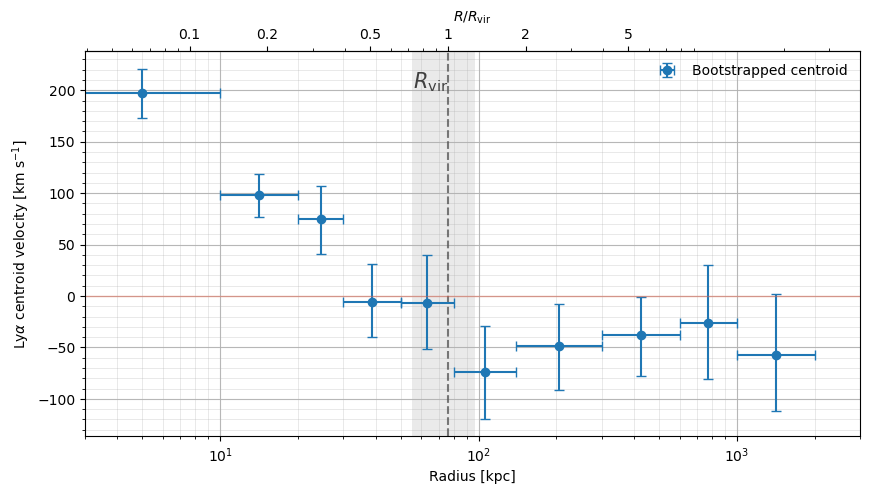

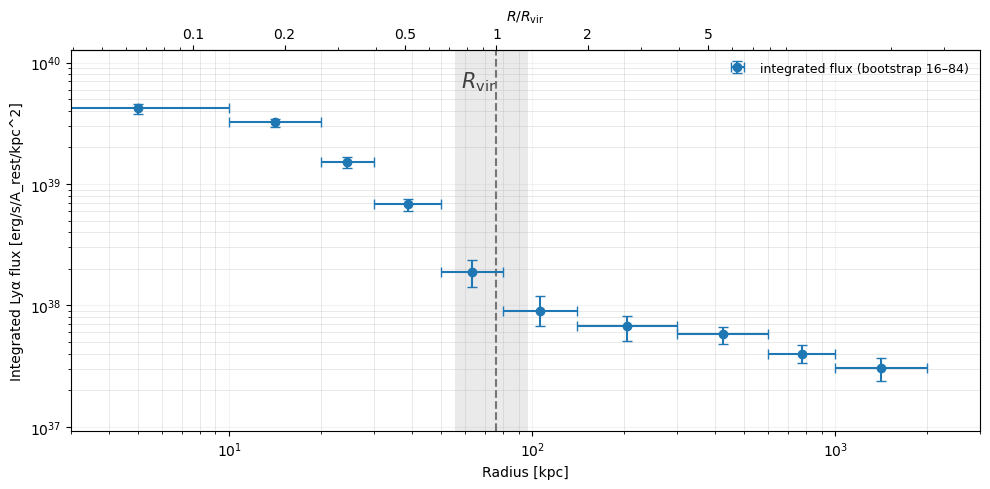

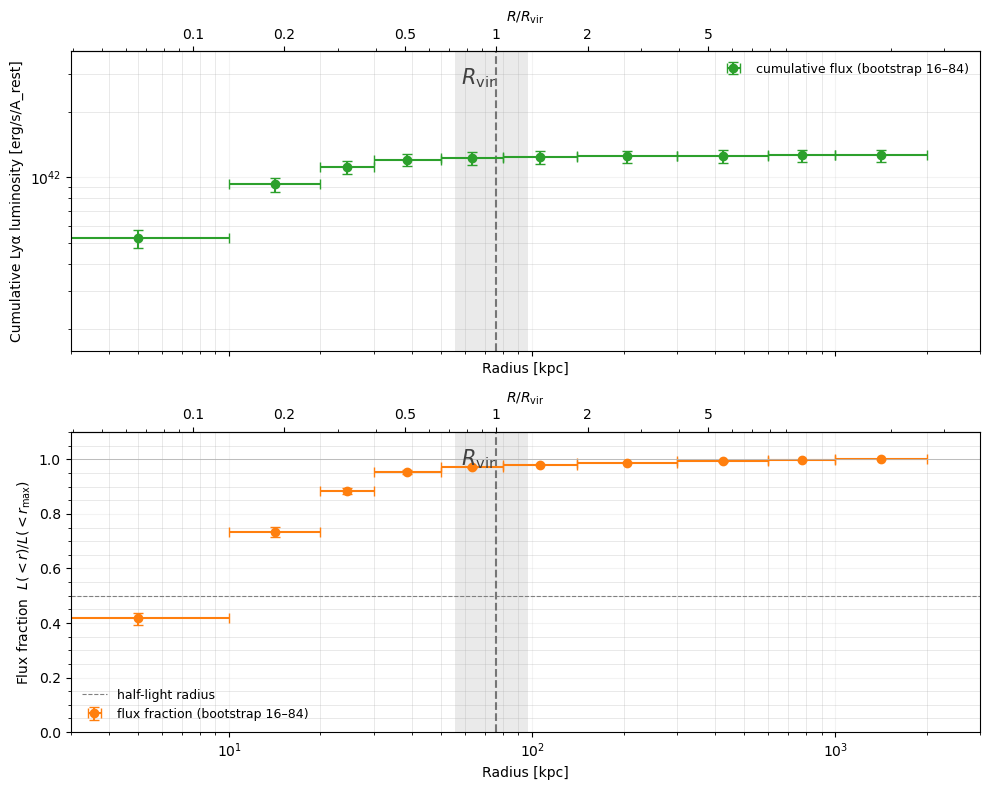

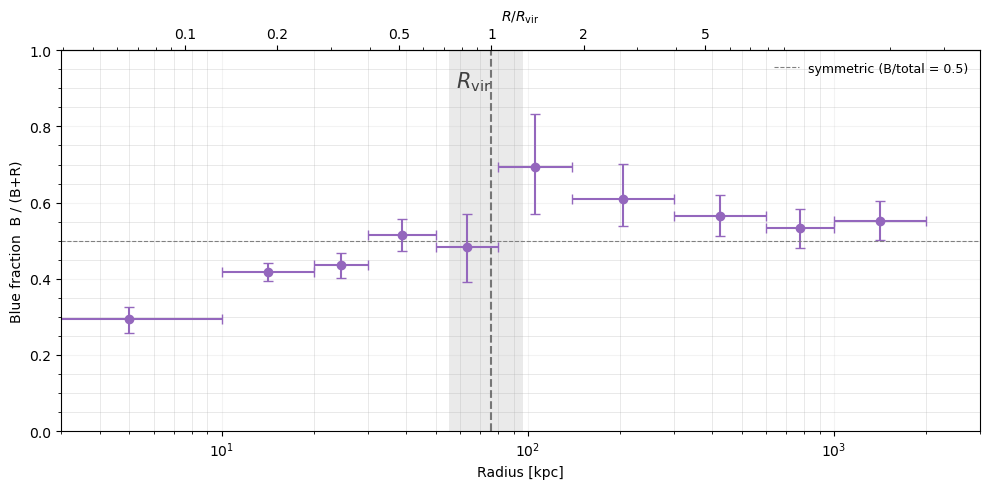

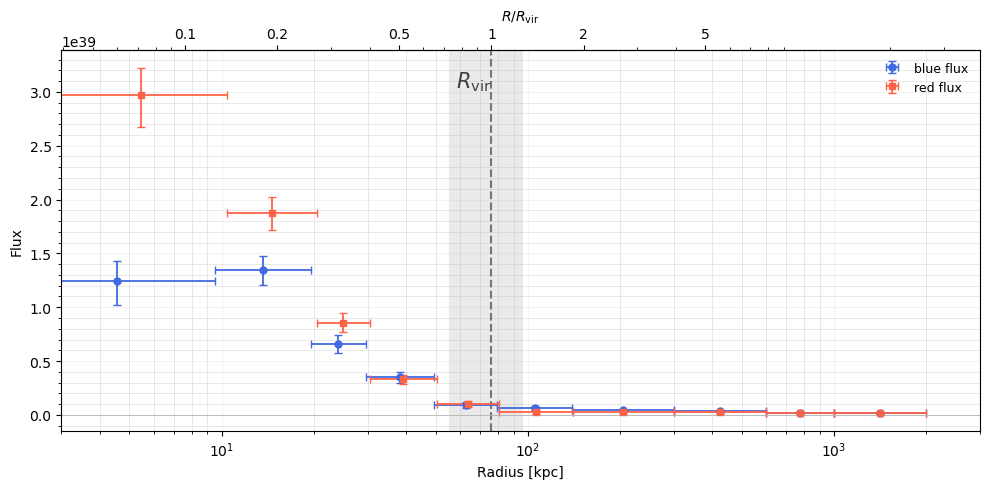

(<Figure size 1000x500 with 1 Axes>,
 <Axes: xlabel='Radius [kpc]', ylabel='Flux'>)

In [13]:
#xlims = (0.03, 30)
xlims = (3, 3000)

# Radial profiles
analysis.plot_centroid_profile(boot, stacks,
    ylims=None,
    xlims=xlims,
    show_vr=True,
    VR_biweight_error=None,
    figsize=(10, 5),
    title=None,                          # or a string; None = no title
    save_fig=True,
    save_name='Centroid_Profile')        # -> Centroid_Profile.png

analysis.plot_flux_profile(boot, stacks,
    ylims=None,
    xlims=xlims,
    show_vr=True,
    VR_biweight_error=None,
    figsize=(10, 5),
    title=None,
    save_fig=False,
    save_name='Surface_Luminosity_Profile')            # -> Flux_Profile.png

analysis.plot_flux_curve_of_growth(cog, stacks,
    xlims=xlims,
    figsize=(10, 8),
    show_vr=True,
    VR_biweight_error=None,
    panels='both',                       # 'both' | 'cumulative' | 'fraction'
    title1=None,                         # None = auto "r_max = ..." title; pass a string to override, or "" / False-y won't suppress it (use panels+title2=None pattern below to fully drop)
    title2=None,
    save_fig=False,
    save_name='Curve_of_Growth')         # -> Curve_of_Growth.png (only if save_fig=True)

analysis.plot_asymmetry_profile(boot, stacks, 
    xlims=xlims,
    panels='fraction',
    show_vr=True,
    VR_biweight_error=None,
    figsize=(10, 5),
    title1=None, 
    save_fig=False,
    save_name='Blue_Fraction')
analysis.plot_asymmetry_profile(boot, stacks, 
    xlims=xlims,
    panels='flux',
    show_vr=True,
    VR_biweight_error=None,
    figsize=(10, 5),
    title2=None,
    save_fig=False,
    save_name='Asymmetry_Flux')

In [15]:
_ = analysis.compare_centroid_methods(stacks, config=cfg2)            # point-estimate table (config-driven continuum)

                  method |       0-10      10-20      20-30      30-50      50-80     80-140    140-300    300-600   600-1000  1000-2000
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 flux-weighted (clipped) |     +139.3      +42.5      +42.2      -19.1      +18.4      -91.5      -71.9      -43.6      -24.9      -15.8
 flux-weighted (no clip) |     +139.3      +42.5      +42.2      -19.1      +81.5     -108.0      -95.4      -43.9      -24.9      -15.8
Gaussian-weighted moment |     +218.7     +111.5      +82.9       +4.1      -11.5      -81.5      -45.1      -53.9      -23.3      -69.0
        Gaussian fit (µ) |     +121.9      +73.6      +54.3      +12.3      -16.7      -85.8      -45.6      -38.3       -9.5      -49.5
          50% cumulative |     +196.5      +98.0      +73.8       -5.7       -8.8      -78.9      -51.6      -39.7      -28.9      -52.5
          parabolic peak |     +279.1    

In [16]:
conf = analysis.measurement_confidence(boot_b, stacks)

       bin       v_fid±err    nσ≠0  flux S/N    ok%  notes
──────────────────────────────────────────────────────────
      0-10   +196.5± 24.2     8.2      10.6   100%  
     10-20    +98.0± 21.1     4.6      13.6   100%  
     20-30    +73.8± 32.9     2.2      10.4   100%  
     30-50     -5.7± 35.6     0.2       8.9   100%  consistent w/ 0
     50-80     -8.8± 45.5     0.2       4.0   100%  consistent w/ 0
    80-140    -78.9± 45.1     1.6       3.4   100%  
   140-300    -51.6± 41.7     1.2       4.5   100%  
   300-600    -39.7± 38.4     1.0       6.3   100%  
  600-1000    -28.9± 55.8     0.5       5.7   100%  consistent w/ 0
 1000-2000    -52.5± 56.7     1.0       4.7   100%  consistent w/ 0

  flux S/N = galaxy-bootstrap stability of integrated flux (not photon S/N).
  nσ≠0 is a gut-check only; use validation.py for real significance.


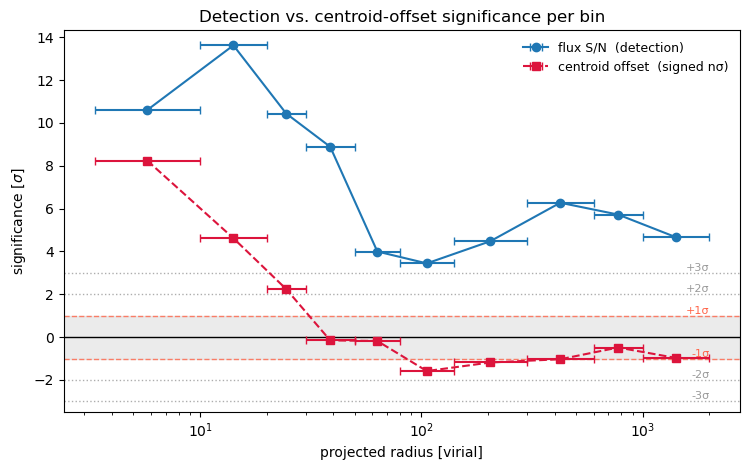

In [17]:
#Plots BOTH curves; centroid is signed from boot["centroid_v_fid"]
fig, ax = plotting.plot_significance_comparison(conf, boot)

# Raw Flux Measurement

In [33]:
cfg_raw = replace(cfg2, 
    flux_unit="flux_arcsec2",
    rest_density=False,
    n_bootstrap=1000)

stacks_raw = build_stacks(cfg_raw, prod_galaxy, keep_cube=True)
stacks_raw_all = build_stacks(cfg_raw, prod_combined, keep_cube=True)

In [34]:
#Fiducial stack
wave  = stacks_raw["rest_wave"]
dwave = np.median(np.diff(wave))
raw_flux = stacks_raw["stacks"]["biweight"]["flux"]
bounds = tuple(cfg_raw.line_window)
flux_curve = []
for r in range(raw_flux.shape[0]):
    res = integrated_line_flux(wave, raw_flux[r], bounds=bounds)
    flux_curve.append(res["flux_integral"] / dwave)
    print(r, res["flux_integral"] / dwave)

0 1.601380034132834e-18
1 1.2692381995774864e-18
2 6.094246253513975e-19
3 2.769866761148061e-19
4 6.546475507885519e-20
5 3.6497664117007355e-20
6 2.5571014144455837e-20
7 2.0499980808348747e-20
8 1.7487705154751868e-20
9 1.2765726614550533e-20


In [35]:
boot_raw = measure.measure_all_bins(cfg_raw, stacks_raw,
    seed=random_seed,
    verbose=True)

▶ bootstrap [median50]  |  nboot=1000  stack=biweight  centroid=median50  window=(1212.67,1218.67)  cont=median  side_ratio=True  stack_err=True  seed=11


bootstrap [median50]:   0%|          | 0/1000 [00:00<?, ?it/s]

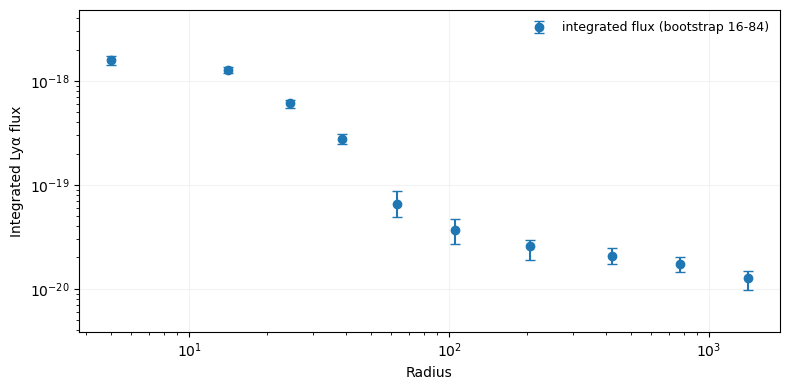

 r_lo  r_hi  r_mid      flux   -1sigma   +1sigma
    0    10      5 1.601e-18 1.739e-19 1.433e-19
   10    20  14.14 1.269e-18 8.849e-20 9.243e-20
   20    30  24.49 6.094e-19 6.107e-20 4.405e-20
   30    50  38.73  2.77e-19 3.238e-20 2.951e-20
   50    80  63.25 6.546e-20 1.638e-20 2.251e-20
   80   140  105.8  3.65e-20 9.348e-21 1.027e-20
  140   300  204.9 2.557e-20 6.832e-21 4.205e-21
  300   600  424.3  2.05e-20 3.043e-21  4.11e-21
  600  1000  774.6 1.749e-20 2.878e-21 2.616e-21
 1000  2000   1414 1.277e-20 2.923e-21  2.07e-21


In [39]:
# --- pull the same quantities plot_flux_profile uses ---
r_edges = np.asarray(boot_raw.get("r_edges", stacks["r_edges"]))
y    = np.asarray(boot_raw["total_flux_fid"])   # boot_raw fiducial (point estimate)
y_lo = np.asarray(boot_raw["total_flux_lo"])    # 16th pctile
y_hi = np.asarray(boot_raw["total_flux_hi"])    # 84th pctile

# geometric bin midpoints (same convention as the pipeline's radius axis)
r_mid = np.sqrt(r_edges[:-1] * r_edges[1:])
if r_edges[0] == 0:
    r_mid[0] = 0.5 * (r_edges[0] + r_edges[1])

# asymmetric 1-sigma errors, guarded against center falling outside [lo, hi]
err_lo = np.clip(y - y_lo, 0, None)
err_hi = np.clip(y_hi - y, 0, None)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(r_mid, y, yerr=[err_lo, err_hi], fmt="o", capsize=3.5, ms=6,
            lw=1.5, color="tab:blue", label="integrated flux (bootstrap 16-84)")
ax.axhline(0, color="0.7", lw=0.7)
ax.set_xscale("log")
pos = y[y > 0]
if len(pos):
    ax.set_yscale("log")
    ax.set_ylim(pos.min() * 0.3, y.max() * 3)
ax.set_xlabel("Radius")
ax.set_ylabel("Integrated Lyα flux")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# --- table ---
table = pd.DataFrame({
    "r_lo": r_edges[:-1],
    "r_hi": r_edges[1:],
    "r_mid": r_mid,
    "flux": y,
    "-1sigma": err_lo,
    "+1sigma": err_hi,
})
print(table.to_string(index=False, float_format=lambda v: f"{v:.4g}"))